In [ ]:
!pip install google-colab-selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [ ]:
import google_colab_selenium as gs

driver = gs.Chrome()

url = 'https://karir.com/search-lowongan?keyword=Medical%20Artificial%20Intelligence%20(AI)&jobFunction=46'
driver.get(url)

print("Access", driver.title)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Access Situs Lowongan Kerja Indonesia | Karir.com


In [ ]:
import pandas as pd
from bs4 import BeautifulSoup
import time

driver.set_window_size(1920, 1080)

url = 'https://karir.com/search-lowongan?keyword=AI%20Engineer'
driver.get(url)
time.sleep(6)

html = driver.page_source
soup = BeautifulSoup(html, 'html.parser')
teks_layar = list(soup.stripped_strings)

data = {
    'job_title': '-', 'company_name': '-', 'location': '-', 'job_type': '-',
    'experience_level': '-', 'education_req': '-', 'salary_range': '-',
    'job_requirements': '-', 'job_responsibilities': '-', 'posted_date': '-',
    'source_platform': 'Karir.com'
}

for i, teks in enumerate(teks_layar):
    if "rp" in teks.lower() and "juta" in teks.lower():
        if data['salary_range'] == '-':
            data['salary_range'] = teks.strip()

            teks_sebelumnya = [t for t in teks_layar[:i] if len(t) > 3 and "•" not in t]

            if len(teks_sebelumnya) >= 2:
                data['company_name'] = teks_sebelumnya[-1]
                data['job_title'] = teks_sebelumnya[-2]

for teks in teks_layar:
    if "202" in teks and any(b in teks.lower() for b in ['jan', 'feb', 'mar', 'apr', 'mei', 'jun', 'jul', 'agu', 'sep', 'okt', 'nov', 'des']):
        if data['posted_date'] == '-':
            data['posted_date'] = teks
            break

def ambil_sebelah(kata_kunci):
    for i, teks in enumerate(teks_layar):
        if kata_kunci.lower() == teks.lower().strip():
            if i + 1 < len(teks_layar): return teks_layar[i + 1]
    return '-'

def ambil_blok(kata_kunci, kata_berhenti):
    for i, teks in enumerate(teks_layar):
        if kata_kunci.lower() in teks.lower():
            blok = []
            for t in teks_layar[i+1:]:
                if any(stop.lower() in t.lower() for stop in kata_berhenti): break
                if len(t) > 2: blok.append(t)
            return " | ".join(blok) if blok else '-'
    return '-'

data['job_type'] = ambil_sebelah('Tipe Pekerjaan')
data['experience_level'] = ambil_sebelah('Minimal Pengalaman')
data['location'] = ambil_sebelah('Kota')

pendidikan = ambil_sebelah('Tingkat Pendidikan')
jurusan = ambil_sebelah('Jurusan Pendidikan')
if pendidikan != '-' or jurusan != '-':
    data['education_req'] = f"{pendidikan} - {jurusan}".strip(" -")

data['job_responsibilities'] = ambil_blok('Job Deskripsi', ['Persyaratan', 'Tingkat Pendidikan', 'Remote/On-site'])
data['job_requirements'] = ambil_blok('Deskripsi Persyaratan', ['Skill yang Dibutuhkan', 'Lokasi', 'Tentang Perusahaan'])

df_lengkap = pd.DataFrame([data])
print("Done!")
display(df_lengkap)

Done!


,job_title,company_name,location,job_type,experience_level,education_req,salary_range,job_requirements,job_responsibilities,posted_date,source_platform
0,Medical Artificial Intelligence (AI) Engineer,PT Daya Medika Pratama,Bandung,Tidak Disebutkan,2 tahun,"S2, S1, D3 - Ilmu Komputer, Manajemen Informat...",Rp 6 juta - Rp 10 juta/bulan,Skills and Qualifications | Technical Expertis...,"Responsibilities | Design, develop, and implem...",9 Juni 2026,Karir.com


In [ ]:
from google.colab import files

nama_file = 'raw_data_karir_ai_engineer.csv'
df_lengkap.to_csv(nama_file, index=False)
files.download(nama_file)

print(f"downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloaded!


In [ ]:
from selenium.webdriver.common.by import By
import google_colab_selenium as gs

driver = gs.Chrome()

driver.set_window_size(1920, 1080)
url_target = 'https://karir.com/search-lowongan?keyword=Finance'
driver.get(url_target)

print("loading halaman Finance...")
time.sleep(10)

soup_list = BeautifulSoup(driver.page_source, 'html.parser')
cards = soup_list.find_all('div', class_=lambda x: x and 'container' in x)

job_cards = []
for c in cards:
    if "lamar" not in c.get_text().lower() and len(c.get_text()) > 50:
        job_cards.append(c)

print(f"Berhasil mendeteksi {len(job_cards)} lowongan potensial.")

semua_hasil = []

for i in range(min(5, len(job_cards))):
    data = {
        'job_title': '-', 'company_name': '-', 'location': '-', 'job_type': '-',
        'experience_level': '-', 'education_req': '-', 'salary_range': '-',
        'job_requirements': '-', 'job_responsibilities': '-', 'posted_date': '-',
        'source_platform': 'Karir.com'
    }

    try:
        card_text = list(job_cards[i].stripped_strings)
        if len(card_text) >= 4:
            data['job_title'] = card_text[0]
            data['company_name'] = card_text[1]
            for t in card_text:
                if "rp" in t.lower(): data['salary_range'] = t
                if any(kota in t for kota in ['Mataram', 'Jakarta', 'Bandung', 'Surabaya']):
                    data['location'] = t

        btn_klik = driver.find_elements(By.XPATH, f"//*[contains(text(), '{data['job_title'][:20]}')]")
        if btn_klik:
            driver.execute_script("arguments[0].click();", btn_klik[0])
            time.sleep(4)

            soup_detail = BeautifulSoup(driver.page_source, 'html.parser')
            teks_detail = list(soup_detail.stripped_strings)

            def ambil_label(label):
                for idx, t in enumerate(teks_detail):
                    if label.lower() == t.lower().strip() and idx+1 < len(teks_detail):
                        return teks_detail[idx+1]
                return '-'

            def ambil_blok(kata_kunci, kata_berhenti):
                for idx, teks in enumerate(teks_detail):
                    if kata_kunci.lower() in teks.lower():
                        blok = []
                        for t in teks_detail[idx+1:]:
                            if any(stop.lower() in t.lower() for stop in kata_berhenti): break
                            if len(t) > 2: blok.append(t)
                        return " | ".join(blok) if blok else '-'
                return '-'

            data['job_type'] = ambil_label('Tipe Pekerjaan')
            data['experience_level'] = ambil_label('Minimal Pengalaman')

            if data['location'] == '-': data['location'] = ambil_label('Kota')

            pend = ambil_label('Tingkat Pendidikan')
            jur = ambil_label('Jurusan Pendidikan')
            if pend != '-': data['education_req'] = f"{pend} - {jur}".strip(" -")

            data['job_responsibilities'] = ambil_blok('Job Deskripsi', ['Persyaratan', 'Tingkat Pendidikan', 'Remote/On-site'])
            data['job_requirements'] = ambil_blok('Deskripsi Persyaratan', ['Skill yang Dibutuhkan', 'Lokasi', 'Tentang Perusahaan'])

            for t in teks_detail:
                if "202" in t and any(b in t.lower() for b in ['jan', 'feb', 'mar', 'apr', 'mei', 'jun', 'jul', 'agu', 'sep', 'okt', 'nov', 'des']):
                    data['posted_date'] = t
                    break

        semua_hasil.append(data)
        print(f"Berhasil menarik data ke-{i+1}: {data['job_title']}")

    except Exception as e:
        print(f"Melewati data ke-{i+1} karena: {e}")

df_banyak = pd.DataFrame(semua_hasil)
df_banyak.index = range(1, len(df_banyak) + 1)

display(df_banyak)

<IPython.core.display.Javascript object>

loading halaman Finance...
Berhasil mendeteksi 0 lowongan potensial.


""


In [ ]:
from google.colab import files

nama_csv = 'raw_dataset_finance_karir.csv'

df_banyak.to_csv(nama_csv, index_label='No')

files.download(nama_csv)
print(f"File {nama_csv} downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File raw_dataset_finance_karir.csv downloaded


<IPython.core.display.Javascript object>

Status Penyamaran Aktif. Membuka Glints...
Judul halaman yang terbaca robot: Lowongan Kerja & Loker Terbaru di Indonesia - Juni 2026 | Glints TapLoker
Berhasil masuk ke halaman utama Glints!
Berhasil mendeteksi 64 lowongan potensial di Glints.
Berhasil menarik data ke-1: Finance Accounting & Tax
Berhasil menarik data ke-2: Finance Accounting & Tax
Berhasil menarik data ke-3: Finance / Bagian Keuangan.
Berhasil menarik data ke-4: Manager Finance Accounting & Tax
Berhasil menarik data ke-5: Manager Finance Accounting Tax


,job_title,company_name,location,job_type,experience_level,education_req,salary_range,job_requirements,job_responsibilities,posted_date,source_platform
1,Finance Accounting & Tax,Minimal Diploma (D1 - D4),Kab. Bekasi,Penuh Waktu,1–3 tahun,Minimal Diploma (D1 - D4),Gaji Tidak Ditampilkan,N/A,N/A,3 hari yang lalu,Glints
2,Finance Accounting & Tax,Minimal Diploma (D1 - D4),Kab. Bekasi,Penuh Waktu,1–3 tahun,Minimal Diploma (D1 - D4),Gaji Tidak Ditampilkan,N/A,N/A,3 hari yang lalu,Glints
3,Finance / Bagian Keuangan.,Minimal Sarjana (S1),Jakarta Barat,Kontrak,1–3 tahun,Minimal Sarjana (S1),Rp 5 jt-7 jt,N/A,N/A,3 hari yang lalu,Glints
4,Manager Finance Accounting & Tax,Minimal Sarjana (S1),Semarang,Penuh Waktu,3–5 tahun,Minimal Sarjana (S1),Rp 5 jt,N/A,N/A,2 hari yang lalu,Glints
5,Manager Finance Accounting Tax,Minimal Sarjana (S1),Jakarta Barat,Kontrak,1–3 tahun,Minimal Sarjana (S1),Rp 10 jt-12 jt,N/A,N/A,7 hari yang lalu,Glints


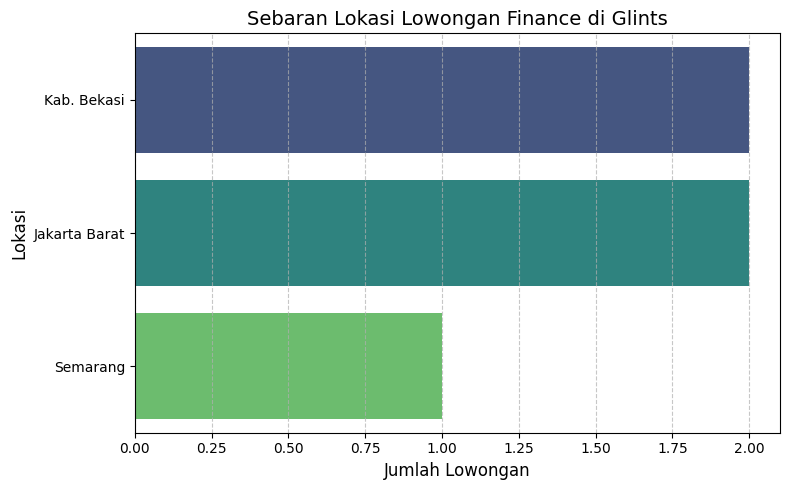

In [ ]:
import pandas as pd
from bs4 import BeautifulSoup
from selenium.webdriver.common.by import By
from selenium import webdriver
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import google_colab_selenium as gs
import matplotlib.pyplot as plt
import seaborn as sns

options = webdriver.ChromeOptions()
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36")

driver = gs.Chrome(options=options)
driver.set_window_size(1920, 1080)

url_glints = 'https://glints.com/id/opportunities/jobs/explore?keyword=finance&country=ID&locationName=All+Cities%2FProvinces'
driver.get(url_glints)

print("Status Penyamaran Aktif. Membuka Glints...")
time.sleep(8)

print("Judul halaman yang terbaca robot:", driver.title)
if "Just a moment" in driver.title or "Cloudflare" in driver.title:
    print("GAWAT! Ketahuan Cloudflare.")
else:
    print("Berhasil masuk ke halaman utama Glints!")

try:
    WebDriverWait(driver, 15).until(
        EC.presence_of_all_elements_located((By.CSS_SELECTOR, "h2, h3"))
    )
except:
    pass

kartu_elemen = driver.find_elements(By.CSS_SELECTOR, "h2, h3")
job_cards = [k for k in kartu_elemen if len(k.text) > 8 and "Glints" not in k.text]

print(f"Berhasil mendeteksi {len(job_cards)} lowongan potensial di Glints.")

semua_hasil_glints = []

for i in range(min(5, len(job_cards))):
    data = {
        'job_title': 'N/A', 'company_name': 'N/A', 'location': 'N/A', 'job_type': 'N/A',
        'experience_level': 'N/A', 'education_req': 'N/A', 'salary_range': 'N/A',
        'job_requirements': 'N/A', 'job_responsibilities': 'N/A', 'posted_date': 'N/A',
        'source_platform': 'Glints'
    }

    try:
        kartu = job_cards[i]
        judul_aktif = kartu.text.split('\n')[0]
        data['job_title'] = judul_aktif

        driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", kartu)
        time.sleep(2)
        driver.execute_script("arguments[0].click();", kartu)
        time.sleep(6)

        soup_detail = BeautifulSoup(driver.page_source, 'html.parser')
        teks_layar = list(soup_detail.stripped_strings)

        idx_mulai = 0
        kemunculan = [idx for idx, t in enumerate(teks_layar) if judul_aktif.lower() == t.lower()]

        if len(kemunculan) >= 2:
            idx_mulai = kemunculan[1]
        elif len(kemunculan) == 1:
            idx_mulai = kemunculan[0]

        idx_akhir = len(teks_layar)
        for idx in range(idx_mulai, len(teks_layar)):
            t = teks_layar[idx].lower()
            if "© 202" in t or "kembali ke atas" in t or "lowongan lainnya untukmu" in t or "laporkan" in t:
                idx_akhir = idx
                break

        teks_detail = teks_layar[idx_mulai:idx_akhir]

        for idx, t in enumerate(teks_detail):
            t_low = t.lower()

            if ("rp" in t_low or "idr" in t_low or "tidak ditampilkan" in t_low) and data['salary_range'] == 'N/A':
                if len(t) < 40: data['salary_range'] = t

            if any(k in t_low for k in ['jakarta', 'bandung', 'surabaya', 'tangerang', 'bekasi', 'bogor', 'depok', 'semarang', 'medan', 'batam', 'bali', 'mataram', 'banten']):
                if "lokasi" not in t_low and 3 < len(t) < 40 and data['location'] == 'N/A':
                    data['location'] = t

            if any(j in t_low for j in ['penuh waktu', 'kontrak', 'magang', 'paruh waktu', 'freelance']):
                if len(t) < 40 and data['job_type'] == 'N/A': data['job_type'] = t.split('·')[0].strip()

            if any(e in t_low for e in ['sma', 'smk', 'diploma', 'sarjana', 's1', 'd3', 'magister', 'gelar']):
                if len(t) < 40 and data['education_req'] == 'N/A': data['education_req'] = t

            if ("hari" in t_low or "jam" in t_low or "menit" in t_low) and "lalu" in t_low:
                if data['posted_date'] == 'N/A': data['posted_date'] = t

            if ("tahun" in t_low or "bulan" in t_low) and data['experience_level'] == 'N/A':
                if len(t) < 40: data['experience_level'] = t

        for t in teks_detail[1:12]:
            t_low = t.lower()
            if t != data['salary_range'] and t != data['location'] and t != judul_aktif and t != data['experience_level']:
                if len(t) < 50:
                    blacklist = ['hari', 'jam', 'menit', 'perusahaan premium', 'aktif merekrut', 'penuh waktu', 'magang', 'kontrak', 'tahun', 'bulan']
                    if not any(b in t_low for b in blacklist):
                        data['company_name'] = t
                        break

        semua_hasil_glints.append(data)
        print(f"Berhasil menarik data ke-{i+1}: {judul_aktif}")

    except Exception as e:
        print(f"Melewati data ke-{i+1} karena gangguan teknis: {e}")

df_glints = pd.DataFrame(semua_hasil_glints)
df_glints.index = range(1, len(df_glints) + 1)
display(df_glints)

if len(df_glints) > 0:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_glints, y='location', hue='location', palette='viridis', legend=False)
    plt.title('Sebaran Lokasi Lowongan Finance di Glints', fontsize=14)
    plt.xlabel('Jumlah Lowongan', fontsize=12)
    plt.ylabel('Lokasi', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
print("Menggabungkan/merge hasil dataset")

df_gabungan = pd.concat([df_lengkap, df_banyak, df_glints], ignore_index=True)

df_gabungan.index = range(1, len(df_gabungan) + 1)

print(f"Selesai! Total data saat ini: {len(df_gabungan)} baris lowongan pekerjaan.")
display(df_gabungan)

Menggabungkan/merge hasil dataset
Selesai! Total data saat ini: 6 baris lowongan pekerjaan.


,job_title,company_name,location,job_type,experience_level,education_req,salary_range,job_requirements,job_responsibilities,posted_date,source_platform
1,Medical Artificial Intelligence (AI) Engineer,PT Daya Medika Pratama,Bandung,Tidak Disebutkan,2 tahun,"S2, S1, D3 - Ilmu Komputer, Manajemen Informat...",Rp 6 juta - Rp 10 juta/bulan,Skills and Qualifications | Technical Expertis...,"Responsibilities | Design, develop, and implem...",9 Juni 2026,Karir.com
2,Finance Accounting & Tax,Minimal Diploma (D1 - D4),Kab. Bekasi,Penuh Waktu,1–3 tahun,Minimal Diploma (D1 - D4),Gaji Tidak Ditampilkan,N/A,N/A,3 hari yang lalu,Glints
3,Finance Accounting & Tax,Minimal Diploma (D1 - D4),Kab. Bekasi,Penuh Waktu,1–3 tahun,Minimal Diploma (D1 - D4),Gaji Tidak Ditampilkan,N/A,N/A,3 hari yang lalu,Glints
4,Finance / Bagian Keuangan.,Minimal Sarjana (S1),Jakarta Barat,Kontrak,1–3 tahun,Minimal Sarjana (S1),Rp 5 jt-7 jt,N/A,N/A,3 hari yang lalu,Glints
5,Manager Finance Accounting & Tax,Minimal Sarjana (S1),Semarang,Penuh Waktu,3–5 tahun,Minimal Sarjana (S1),Rp 5 jt,N/A,N/A,2 hari yang lalu,Glints
6,Manager Finance Accounting Tax,Minimal Sarjana (S1),Jakarta Barat,Kontrak,1–3 tahun,Minimal Sarjana (S1),Rp 10 jt-12 jt,N/A,N/A,7 hari yang lalu,Glints


In [ ]:
from google.colab import files

nama_file_final = 'raw_dataset_gabungan_tahap1.csv'
df_gabungan.to_csv(nama_file_final, index_label='No')

files.download(nama_file_final)
print(f"File {nama_file_final} berhasil diunduh!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File raw_dataset_gabungan_tahap1.csv berhasil diunduh!


## DATA CLEANING (VERACITY)

In [ ]:
import numpy as np
import re

df = pd.read_csv('raw_dataset_gabungan_tahap1.csv')

nilai_kosong = ['-', 'N/A', 'NaN', '', ' ']
df.replace(nilai_kosong, np.nan, inplace=True)

df['job_type'] = df['job_type'].fillna('Tidak Disebutkan')
df['job_type'] = df['job_type'].str.strip()

def bersihkan_gaji(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('\xa0', ' ').strip()
    s = re.sub(r'\bjt\b', 'juta', s, flags=re.IGNORECASE)
    return s

df['salary_range'] = df['salary_range'].apply(bersihkan_gaji)

def standardisasi_exp(s):
    if pd.isna(s): return 'Tidak Disebutkan'
    s = str(s).strip()
    return s

df['experience_level'] = df['experience_level'].apply(standardisasi_exp)

def standardisasi_tanggal(s):
    if pd.isna(s): return 'Tidak Diketahui'
    s = str(s)
    if 'hari yang lalu' in s or 'jam yang lalu' in s or 'menit yang lalu' in s:
        return 'Baru (< 2 minggu)'
    return s

df['posted_date'] = df['posted_date'].apply(standardisasi_tanggal)

print("=== LAPORAN DATA CLEANING ===")
print(f"Total baris: {len(df)}")
print(f"\nJumlah NaN per kolom setelah cleaning:")
print(df.isnull().sum())

df.to_csv('cleaned_dataset_tahap2.csv', index_label='No')
print("\nFile 'cleaned_dataset_tahap2.csv' berhasil disimpan!")
display(df)

=== LAPORAN DATA CLEANING ===
Total baris: 6

Jumlah NaN per kolom setelah cleaning:
No                      0
job_title               0
company_name            0
location                0
job_type                0
experience_level        0
education_req           0
salary_range            0
job_requirements        5
job_responsibilities    5
posted_date             0
source_platform         0
dtype: int64

File 'cleaned_dataset_tahap2.csv' berhasil disimpan!


,No,job_title,company_name,location,job_type,experience_level,education_req,salary_range,job_requirements,job_responsibilities,posted_date,source_platform
0,1,Medical Artificial Intelligence (AI) Engineer,PT Daya Medika Pratama,Bandung,Tidak Disebutkan,2 tahun,"S2, S1, D3 - Ilmu Komputer, Manajemen Informat...",Rp 6 juta - Rp 10 juta/bulan,Skills and Qualifications | Technical Expertis...,"Responsibilities | Design, develop, and implem...",9 Juni 2026,Karir.com
1,2,Finance Accounting & Tax,Minimal Diploma (D1 - D4),Kab. Bekasi,Penuh Waktu,1–3 tahun,Minimal Diploma (D1 - D4),Gaji Tidak Ditampilkan,NaN,NaN,Baru (< 2 minggu),Glints
2,3,Finance Accounting & Tax,Minimal Diploma (D1 - D4),Kab. Bekasi,Penuh Waktu,1–3 tahun,Minimal Diploma (D1 - D4),Gaji Tidak Ditampilkan,NaN,NaN,Baru (< 2 minggu),Glints
3,4,Finance / Bagian Keuangan.,Minimal Sarjana (S1),Jakarta Barat,Kontrak,1–3 tahun,Minimal Sarjana (S1),Rp 5 juta-7 juta,NaN,NaN,Baru (< 2 minggu),Glints
4,5,Manager Finance Accounting & Tax,Minimal Sarjana (S1),Semarang,Penuh Waktu,3–5 tahun,Minimal Sarjana (S1),Rp 5 juta,NaN,NaN,Baru (< 2 minggu),Glints
5,6,Manager Finance Accounting Tax,Minimal Sarjana (S1),Jakarta Barat,Kontrak,1–3 tahun,Minimal Sarjana (S1),Rp 10 juta-12 juta,NaN,NaN,Baru (< 2 minggu),Glints


## EXPLORATORY DATA ANALYSIS & VISUALISASI (VALUE)

/tmp/ipykernel_1350/3581126743.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lokasi_count.values, y=lokasi_count.index,
/tmp/ipykernel_1350/3581126743.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_type_count.values, y=job_type_count.index,
/tmp/ipykernel_1350/3581126743.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exp_count.values, y=exp_count.index,


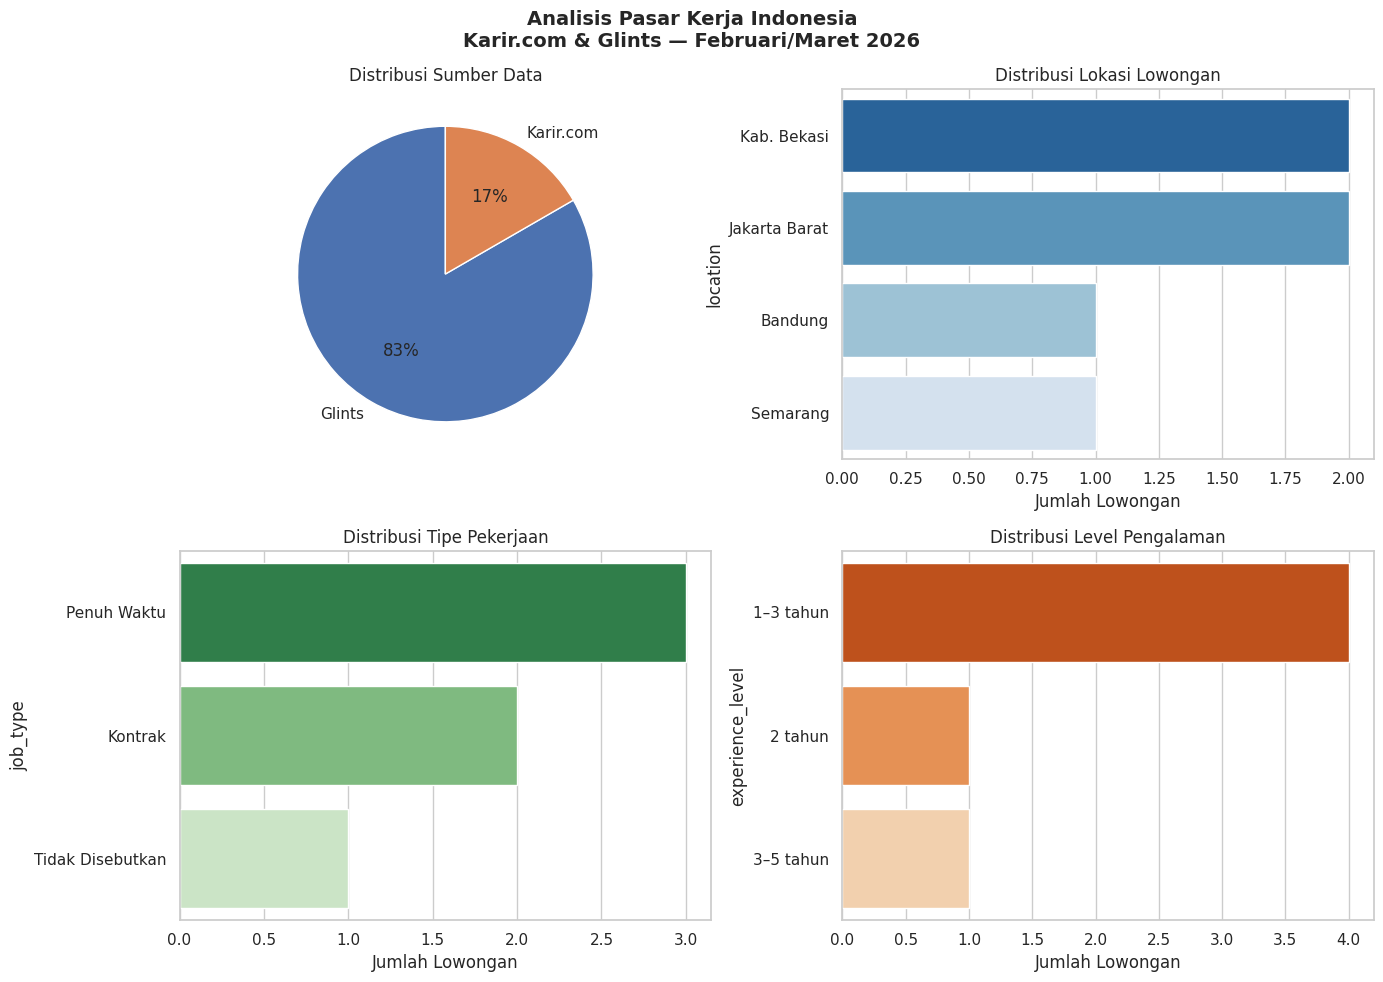

Visualisasi berhasil disimpan sebagai 'eda_visualisasi.png'

=== TOP 10 KATA PADA JUDUL LOWONGAN ===
  finance              → 5x
  accounting           → 4x
  medical              → 1x
  artificial           → 1x
  intelligence         → 1x
  engineer             → 1x
  bagian               → 1x
  keuangan             → 1x

=== RINGKASAN STATISTIK ===
Total lowongan     : 6
Platform sumber    : 2 (Karir.com, Glints)
Kota yang tercakup : 4
Lowongan dengan gaji tercantum : 6
Lowongan tanpa gaji            : 0


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Pasar Kerja Indonesia\nKarir.com & Glints — Februari/Maret 2026',
             fontsize=14, fontweight='bold')

platform_count = df['source_platform'].value_counts()
axes[0,0].pie(platform_count, labels=platform_count.index,
              autopct='%1.0f%%', colors=['#4C72B0','#DD8452'], startangle=90)
axes[0,0].set_title('Distribusi Sumber Data')

lokasi_count = df['location'].value_counts().head(8)
sns.barplot(x=lokasi_count.values, y=lokasi_count.index,
            ax=axes[0,1], palette='Blues_r')
axes[0,1].set_title('Distribusi Lokasi Lowongan')
axes[0,1].set_xlabel('Jumlah Lowongan')

job_type_count = df['job_type'].value_counts()
sns.barplot(x=job_type_count.values, y=job_type_count.index,
            ax=axes[1,0], palette='Greens_r')
axes[1,0].set_title('Distribusi Tipe Pekerjaan')
axes[1,0].set_xlabel('Jumlah Lowongan')

exp_count = df['experience_level'].value_counts()
sns.barplot(x=exp_count.values, y=exp_count.index,
            ax=axes[1,1], palette='Oranges_r')
axes[1,1].set_title('Distribusi Level Pengalaman')
axes[1,1].set_xlabel('Jumlah Lowongan')

plt.tight_layout()
plt.savefig('eda_visualisasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi berhasil disimpan sebagai 'eda_visualisasi.png'")

from collections import Counter
import re

semua_kata = []
for judul in df['job_title'].dropna():
    kata = re.findall(r'\b[a-zA-Z]{4,}\b', judul.lower())
    semua_kata.extend(kata)

stopword = {'staff', 'manager', 'untuk', 'yang', 'dengan', 'dari', 'dan'}
kata_bersih = [k for k in semua_kata if k not in stopword]
top_kata = Counter(kata_bersih).most_common(10)

print("\n=== TOP 10 KATA PADA JUDUL LOWONGAN ===")
for kata, freq in top_kata:
    print(f"  {kata:<20} → {freq}x")

print("\n=== RINGKASAN STATISTIK ===")
print(f"Total lowongan     : {len(df)}")
print(f"Platform sumber    : {df['source_platform'].nunique()} ({', '.join(df['source_platform'].unique())})")
print(f"Kota yang tercakup : {df['location'].nunique()}")
print(f"Lowongan dengan gaji tercantum : {df['salary_range'].notna().sum()}")
print(f"Lowongan tanpa gaji            : {df['salary_range'].isna().sum()}")